In [2]:
import numpy as np
import matplotlib.pyplot as plt

### 1.d

In [9]:
def accept_reject(func, xrange, size, ymax=None):
    if ymax is None:
        x_test = np.linspace(xrange[0], xrange[1], 1000)
        ymax = np.max(func(x_test)) * 1.05
    
    samples = []
    
    while len(samples) < size:
        x = np.random.uniform(xrange[0], xrange[1])
        u = np.random.uniform(0, ymax)
        y = func(x)
        
        if y > ymax:
            ymax = y * 1.1
        
        if u <= y:
            samples.append(x)
            
    return np.array(samples)

In [10]:
# PDF
alpha = 0.5
beta = 0.5
a = -0.95
b = 0.95

def d_k(k, a, b):
    return (b**k - a**k) / k

d1 = d_k(1, a, b)
d2 = d_k(2, a, b)
d3 = d_k(3, a, b)
d4 = d_k(4, a, b)
d5 = d_k(5, a, b)

N = 1 / (d1 + alpha*d2 + beta*d3)

In [11]:
def pdf(x):
    if np.isscalar(x):
        if x < a or x > b:
            return 0
        return N * (1 + alpha*x + beta*x**2)
    else:
        result = np.zeros_like(x)
        mask = (x >= a) & (x <= b)
        result[mask] = N * (1 + alpha*x[mask] + beta*x[mask]**2)
        return result

In [19]:
samples = accept_reject(pdf, (a, b), 1000)

In [21]:
x_plot = np.linspace(a, b, 1000)
y_plot = pdf(x_plot)

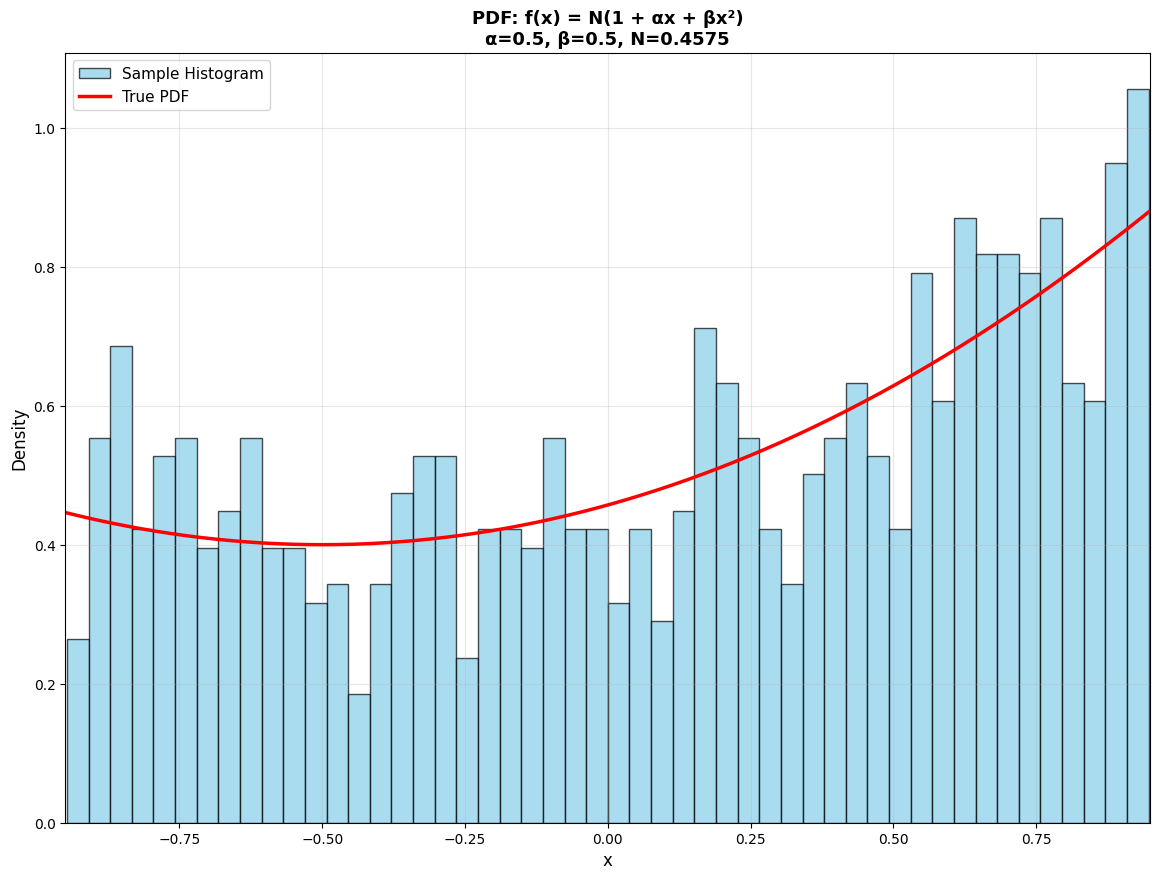

In [30]:
# Sample Histogram vs PDF
x_plot = np.linspace(a, b, 1000)
y_plot = pdf(x_plot)

fig = plt.figure(figsize=(14, 10))
plt.hist(samples, bins=50, density=True, alpha=0.7, color='skyblue', edgecolor='black', label='Sample Histogram')
plt.plot(x_plot, y_plot, 'r-', linewidth=2.5, label='True PDF')
plt.xlabel('x', fontsize=12)
plt.ylabel('Density', fontsize=12)
plt.title(f'PDF: f(x) = N(1 + αx + βx²)\nα={alpha}, β={beta}, N={N:.4f}', fontsize=13, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim(a, b)
plt.show()

### 1.e